In [2]:
import pandas as pd
import numpy as np
import os
import glob
import statsmodels.api as sm


In [3]:
# path to folder
folder_path = "./Task2Data/*"

# get list of csv files
files = glob.glob(folder_path)

structural = {}
functional = {}

for file in files:

    name = os.path.basename(file)
    subject = name.split("_")[0]   # extracts subject ID

    mat = pd.read_csv(file, comment='#', header=None).values

    if "WFA" in name:
        structural[subject] = mat

    elif "rsfMRI" in name:
        functional[subject] = mat

print(len(structural), len(functional))

19 19


In [4]:
def indirect_connectivity(S):

    n = S.shape[0]
    T = np.zeros_like(S)

    for i in range(n):
        for j in range(n):

            if i == j:
                continue

            vals = []

            for k in range(n):

                if S[i,k] > 0 and S[k,j] > 0:
                    vals.append(min(S[i,k], S[k,j]))

            if vals:
                T[i,j] = max(vals)

    return T

In [5]:
T_matrices = {}

for subject in structural:

    S = structural[subject]
    T = indirect_connectivity(S)

    T_matrices[subject] = T

T_matrices


{'32': array([[0.        , 0.42255735, 0.40971658, ..., 0.        , 0.        ,
         0.42255735],
        [0.42255735, 0.        , 0.49604311, ..., 0.32162235, 0.46948489,
         0.45943316],
        [0.40971658, 0.49604311, 0.        , ..., 0.34516057, 0.46948489,
         0.43447875],
        ...,
        [0.        , 0.32162235, 0.34516057, ..., 0.        , 0.34516057,
         0.34516057],
        [0.        , 0.46948489, 0.46948489, ..., 0.34516057, 0.        ,
         0.42188022],
        [0.42255735, 0.45943316, 0.43447875, ..., 0.34516057, 0.42188022,
         0.        ]]),
 '33': array([[0.        , 0.41149768, 0.43011361, ..., 0.        , 0.        ,
         0.43516083],
        [0.41149768, 0.        , 0.48380023, ..., 0.28125498, 0.49564331,
         0.44916189],
        [0.43011361, 0.48380023, 0.        , ..., 0.28125498, 0.48380023,
         0.48352925],
        ...,
        [0.        , 0.28125498, 0.28125498, ..., 0.        , 0.28125498,
         0.28125498],


In [6]:
subjects = list(structural.keys())
# Get the number of regions from one of the structural matrices
num_regions = structural[subjects[0]].shape[0]

## Refit All Models with AIC/BIC


In [7]:
def get_features(structural_data, indirect_structural_data, subjects, region_i, region_j, include_s, include_t, include_s2, include_t2):
  exog = []
  if include_s:
    s_ij = np.array([structural_data[s][region_i, region_j] for s in subjects])
    exog.append(s_ij)
  if include_t:
    t_ij = np.array([indirect_structural_data[s][region_i, region_j] for s in subjects])
    exog.append(t_ij)
  if include_s2:
    if not include_s:
      s_ij = np.array([structural_data[s][region_i, region_j] for s in subjects])
    exog.append(s_ij**2)
  if include_t2:
    if not include_t:
      t_ij = np.array([indirect_structural_data[s][region_i, region_j] for s in subjects])
    exog.append(t_ij**2)
  return exog


def fit_generalized_model(functional_data, structural_data, indirect_structural_data, subject_list, region_i, region_j, include_s, include_t, include_s2, include_t2):
    """
    Fits a generalized linear model for functional connectivity and returns coefficients, AIC, and BIC.

    Args:
        functional_data (dict): Dictionary of functional connectivity matrices per subject.
        structural_data (dict): Dictionary of structural connectivity matrices per subject.
        indirect_structural_data (dict): Dictionary of indirect structural connectivity
                                        matrices (T_matrices) per subject.
        subject_list (list): List of subject IDs.
        region_i (int): First brain region index.
        region_j (int): Second brain region index.
        include_s (bool): Whether to include direct structural connectivity (s_ij).
        include_t (bool): Whether to include indirect structural connectivity (t_ij).
        include_s2 (bool): Whether to include squared direct structural connectivity (s_ij^2).
        include_t2 (bool): Whether to include squared indirect structural connectivity (t_ij^2).

    Returns:
        dict or None: A map, containing the parameters, aic and bic if
                               the model is fitted successfully, otherwise None.
    """

    f_ij = np.array([functional_data[s][region_i, region_j] for s in subject_list])

    exog_vars = get_features(structural_data, indirect_structural_data, subject_list, region_i, region_j, include_s, include_t, include_s2, include_t2)

    if not exog_vars or np.all(np.column_stack(exog_vars) == 0):
        return None

    X = np.column_stack(exog_vars)
    X = sm.add_constant(X)

    model = sm.OLS(f_ij, X).fit()

    return model

In [8]:
model1_results = {}
model2_results = {}
model3_results = {}
model4_results = {}
model5_results = {}

for i in range(num_regions):
    for j in range(num_regions):
        if i == j:
            continue

        # Model 1: fij = ̑̑ij + ̒̑ij sij
        res1 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=True, include_t=False, include_s2=False, include_t2=False)
        if res1 is not None:
            model1_results[(i, j)] = res1

        # Model 2: fij = ̑̑ij + ̒̑ij sij + ̓ij sij^2
        res2 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=True, include_t=False, include_s2=True, include_t2=False)
        if res2 is not None:
            model2_results[(i, j)] = res2

        # Model 3: fij = ̑̑ij + ̒̑ij tij
        res3 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=False, include_t=True, include_s2=False, include_t2=False)

        if res3 is not None:
            model3_results[(i, j)] = res3

        # Model 4: fij = ̑̑ij + ̒̑ij tij + ̓ij tij^2
        res4 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=False, include_t=True, include_s2=False, include_t2=True)
        if res4 is not None:
            model4_results[(i, j)] = res4

        # Model 5: fij = ̑̑ij + ̒̑ij sij + ̓ij tij
        res5 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=True, include_t=True, include_s2=False, include_t2=False)
        if res5 is not None:
            model5_results[(i, j)] = res5

print(f'Refitted models for {num_regions} regions. Example entry (0,2) Model 1 AIC: {model1_results[(0,2)].aic}')

Refitted models for 68 regions. Example entry (0,2) Model 1 AIC: -52.19583544402778


## Implement Leave-One-Out Cross-Validation

In [9]:
def perform_loocv(functional_data, structural_data, indirect_structural_data, subject_list, region_i, region_j, include_s, include_t, include_s2, include_t2):
    """
    Evaluates model predictive performance using Leave-One-Out Cross-Validation (LOOCV).
    Returns the total Sum of Squared Errors (SSE) across all subjects.
    """
    total_sse = 0
    num_subjects = len(subject_list)

    for idx in range(num_subjects):
        # Define training and test subjects
        test_subject = subject_list[idx]
        train_subjects = [s for i, s in enumerate(subject_list) if i != idx]

        # Fit model on training set
        model = fit_generalized_model(functional_data, structural_data, indirect_structural_data, train_subjects, region_i, region_j, include_s, include_t, include_s2, include_t2)
        if model is None:
            continue

        # Prepare test data
        y_test = functional_data[test_subject][region_i, region_j]
        X_test_raw = get_features(structural_data, indirect_structural_data,[test_subject],region_i, region_j, include_s, include_t, include_s2, include_t2)

        if X_test_raw is not None:
          X_test_raw = np.column_stack(X_test_raw)
        X_test = sm.add_constant(X_test_raw, has_constant='add')

        # Predict and calculate squared error
        prediction = model.predict(X_test)[0]
        squared_error = (y_test - prediction)**2
        total_sse += squared_error

    return total_sse

## Calculate SSE for All Models

### Subtask:
Iterate through all brain region pairs and compute the total Sum of Squared Errors (SSE) for each of the five models using the perform_loocv function.


**Reasoning**:
I will initialize the SSE dictionaries and iterate through all brain region pairs to compute the LOOCV SSE for all five models using the previously defined perform_loocv function.



In [10]:
sse_model1 = {}
sse_model2 = {}
sse_model3 = {}
sse_model4 = {}
sse_model5 = {}

for i in range(num_regions):
    for j in range(num_regions):
        if i == j:
            continue

        # Model 1: s_ij
        sse1 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=True, include_t=False, include_s2=False, include_t2=False)
        if sse1 is not None:
            sse_model1[(i, j)] = sse1

        # Model 2: s_ij + s_ij^2
        sse2 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=True, include_t=False, include_s2=True, include_t2=False)
        if sse2 is not None:
            sse_model2[(i, j)] = sse2

        # Model 3: t_ij
        sse3 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=False, include_t=True, include_s2=False, include_t2=False)
        if sse3 is not None:
            sse_model3[(i, j)] = sse3

        # Model 4: t_ij + t_ij^2
        sse4 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=False, include_t=True, include_s2=False, include_t2=True)
        if sse4 is not None:
            sse_model4[(i, j)] = sse4

        # Model 5: s_ij + t_ij
        sse5 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=True, include_t=True, include_s2=False, include_t2=False)
        if sse5 is not None:
            sse_model5[(i, j)] = sse5

print(f"LOOCV SSE calculation completed for {num_regions} regions.")

LOOCV SSE calculation completed for 68 regions.


## Plot Model Comparison


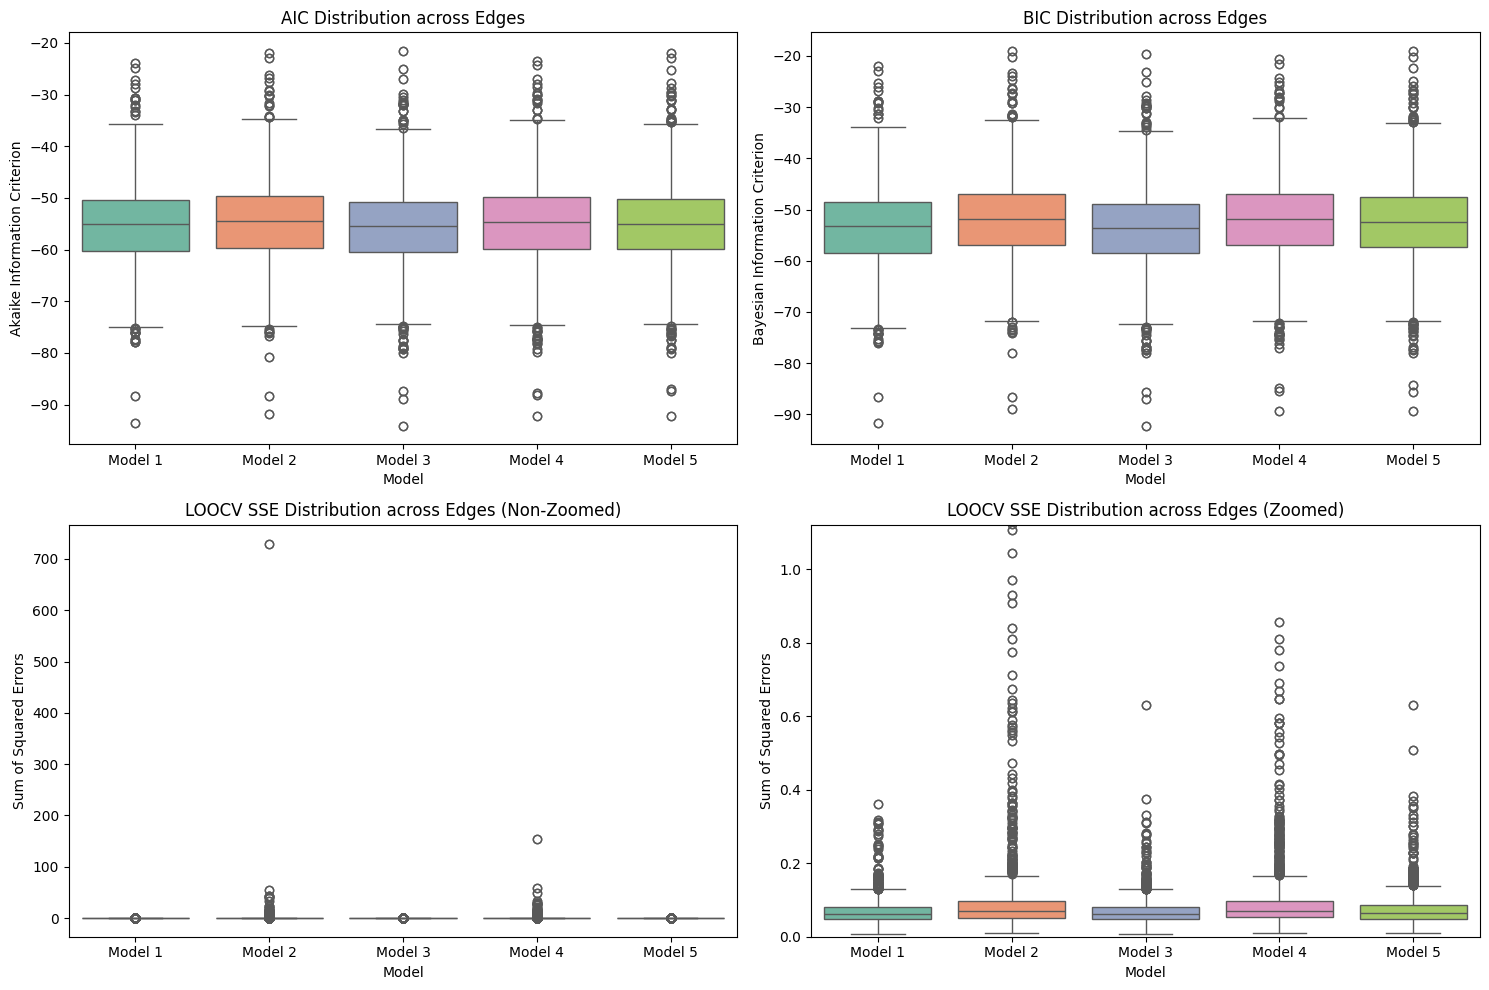

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data lists for AIC, BIC, and SSE
data = []

model_names = ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5']
res_dicts = [model1_results, model2_results, model3_results, model4_results, model5_results]
sse_dicts = [sse_model1, sse_model2, sse_model3, sse_model4, sse_model5]

for idx, m_name in enumerate(model_names):
    current_res = res_dicts[idx]
    current_sse = sse_dicts[idx]

    # Get common keys (edges) present in both results and SSE for consistency
    common_keys = set(current_res.keys()) & set(current_sse.keys())

    for key in common_keys:
        data.append({
            'Model': m_name,
            'AIC': current_res[key].aic,
            'BIC': current_res[key].bic,
            'SSE': current_sse[key]
        })

# Create DataFrame
comparison_df = pd.DataFrame(data)

# Plotting: Create a 2x2 grid for the plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# AIC Box Plot (Top-Left)
sns.boxplot(data=comparison_df, x='Model', y='AIC', ax=axes[0, 0], palette='Set2', hue='Model', legend=False)
axes[0, 0].set_title('AIC Distribution across Edges')
axes[0, 0].set_ylabel('Akaike Information Criterion')

# BIC Box Plot (Top-Right)
sns.boxplot(data=comparison_df, x='Model', y='BIC', ax=axes[0, 1], palette='Set2', hue='Model', legend=False)
axes[0, 1].set_title('BIC Distribution across Edges')
axes[0, 1].set_ylabel('Bayesian Information Criterion')

# Non-zoomed SSE Box Plot (Bottom-Left)
sns.boxplot(data=comparison_df, x='Model', y='SSE', ax=axes[1, 0], palette='Set2', hue='Model', legend=False)
axes[1, 0].set_title('LOOCV SSE Distribution across Edges (Non-Zoomed)')
axes[1, 0].set_ylabel('Sum of Squared Errors')

# Zoomed SSE Box Plot (Bottom-Right)
sns.boxplot(data=comparison_df, x='Model', y='SSE', ax=axes[1, 1], palette='Set2', hue='Model', legend=False)
axes[1, 1].set_title('LOOCV SSE Distribution across Edges (Zoomed)')
axes[1, 1].set_ylabel('Sum of Squared Errors')

# Set y-axis limit for the zoomed SSE plot
upper_limit_sse = comparison_df['SSE'].quantile(0.99)
axes[1, 1].set_ylim(0, upper_limit_sse)

plt.tight_layout()
plt.show()

Based on the plots, seems that model 3 is the one that performs the best

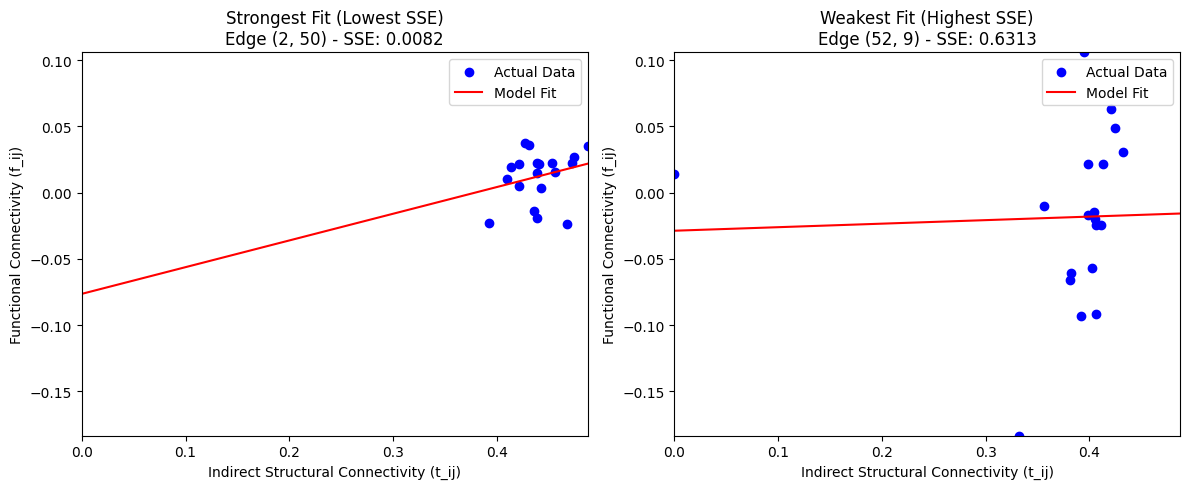

In [12]:
# Get common keys present in both results and SSE for consistency
common_keys = set(model3_results.keys()) & set(sse_model3.keys())

# Filter sse_model3 to only include common keys
filtered_sse_model3 = {k: sse_model3[k] for k in common_keys}

if not filtered_sse_model3:
    print("No common edges found between Model 3 results and SSE. Cannot plot best/worst fit.")
else:
    best_edge = min(filtered_sse_model3, key=filtered_sse_model3.get)
    worst_edge = max(filtered_sse_model3, key=filtered_sse_model3.get)

    edges_to_plot = {
        "Strongest Fit (Lowest SSE)": best_edge,
        "Weakest Fit (Highest SSE)": worst_edge
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    all_t_ij_vals = []
    all_f_ij_vals = []

    for title, edge in edges_to_plot.items():
        i, j = edge
        t_ij_temp = np.array([T_matrices[s][i, j] for s in subjects])
        f_ij_temp = np.array([functional[s][i, j] for s in subjects])
        all_t_ij_vals.extend(t_ij_temp)
        all_f_ij_vals.extend(f_ij_temp)

    # Determine global min/max for consistent scaling
    global_t_ij_min = min(all_t_ij_vals)
    global_t_ij_max = max(all_t_ij_vals)
    global_f_ij_min = min(all_f_ij_vals)
    global_f_ij_max = max(all_f_ij_vals)

    for ax_idx, (title, edge) in enumerate(edges_to_plot.items()):
        ax = axes[ax_idx]
        i, j = edge

        # Use t_ij because model uses the indirect edges
        t_ij = np.array([T_matrices[s][i, j] for s in subjects])
        f_ij = np.array([functional[s][i, j] for s in subjects])

        # Get model result for the current edge
        model_result = model3_results[edge]

        # For Model 3, it's fij = beta0 + beta1 * t_ij. params will have 2 elements.
        intercept = model_result.params[0]
        slope = model_result.params[1]

        # Scatter plot of the raw data
        ax.scatter(t_ij, f_ij, color='blue', label='Actual Data')

        # Plot the regression line
        # We use global min and max of t_ij to draw the line across the full range of the data
        x_vals = np.linspace(global_t_ij_min, global_t_ij_max, 100)
        y_vals = intercept + slope * x_vals
        ax.plot(x_vals, y_vals, color='red', label='Model Fit')

        # Formatting the plot
        ax.set_title(f"{title}\nEdge ({i}, {j}) - SSE: {sse_model3[edge]:.4f}")
        ax.set_xlabel("Indirect Structural Connectivity (t_ij)")
        ax.set_ylabel("Functional Connectivity (f_ij)")
        ax.legend()

        # Set consistent x and y limits
        ax.set_xlim(global_t_ij_min, global_t_ij_max)
        ax.set_ylim(global_f_ij_min, global_f_ij_max)

    plt.tight_layout()
    plt.show()

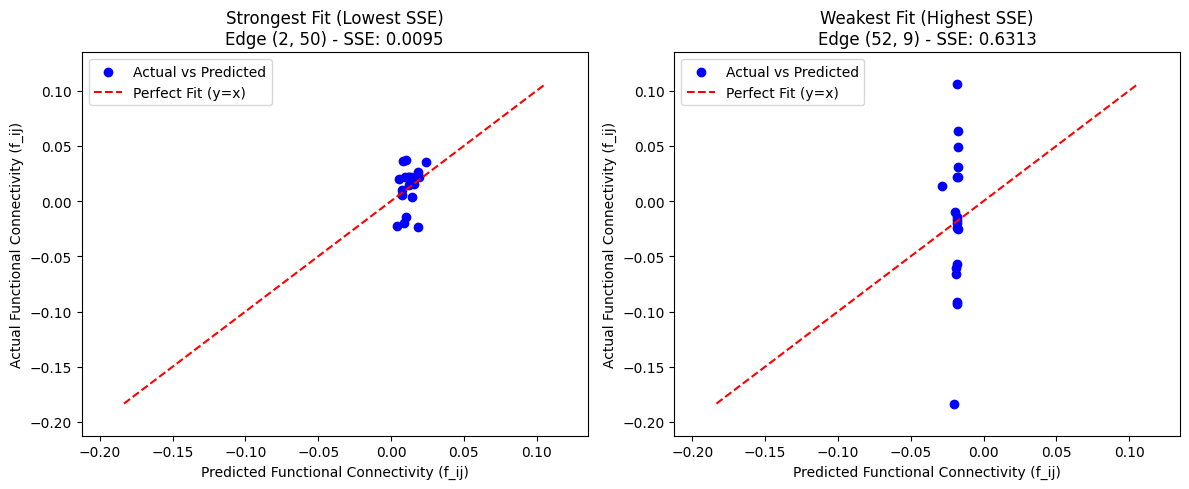

In [13]:
# Get common keys present in both results and SSE for consistency
common_keys_model5 = set(model5_results.keys()) & set(sse_model5.keys())

# Filter sse_model5 to only include common keys
filtered_sse_model5 = {k: sse_model5[k] for k in common_keys_model5}

if not filtered_sse_model5:
    print("No common edges found between Model 5 results and SSE. Cannot plot best/worst fit.")
else:
    best_edge_model5 = min(filtered_sse_model5, key=filtered_sse_model5.get)
    worst_edge_model5 = max(filtered_sse_model5, key=filtered_sse_model5.get)

    edges_to_plot_model5 = {
        "Strongest Fit (Lowest SSE)": best_edge_model5,
        "Weakest Fit (Highest SSE)": worst_edge_model5
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    all_actual_f_ij_vals = []
    all_predicted_f_ij_vals = []

    for title, edge in edges_to_plot_model5.items():
        i, j = edge

        # Actual functional connectivity values
        f_ij_actual = np.array([functional[s][i, j] for s in subjects])

        # Prepare exogenous variables for prediction
        s_ij = np.array([structural[s][i, j] for s in subjects])
        t_ij = np.array([T_matrices[s][i, j] for s in subjects])
        X_pred = np.column_stack([s_ij, t_ij]) # Model 5 uses both s_ij and t_ij
        X_pred = sm.add_constant(X_pred) # Add constant term

        # Get model result for the current edge and predict
        model_result = model5_results[edge]
        predicted_f_ij = model_result.predict(X_pred)

        all_actual_f_ij_vals.extend(f_ij_actual)
        all_predicted_f_ij_vals.extend(predicted_f_ij)

    # Determine global min/max for consistent scaling
    global_min_val = min(min(all_actual_f_ij_vals), min(all_predicted_f_ij_vals))
    global_max_val = max(max(all_actual_f_ij_vals), max(all_predicted_f_ij_vals))

    # Add some padding to the limits
    padding = (global_max_val - global_min_val) * 0.1
    x_lim = (global_min_val - padding, global_max_val + padding)
    y_lim = (global_min_val - padding, global_max_val + padding)

    for ax_idx, (title, edge) in enumerate(edges_to_plot_model5.items()):
        ax = axes[ax_idx]
        i, j = edge

        f_ij_actual = np.array([functional[s][i, j] for s in subjects])

        s_ij = np.array([structural[s][i, j] for s in subjects])
        t_ij = np.array([T_matrices[s][i, j] for s in subjects])
        X_pred = np.column_stack([s_ij, t_ij])
        X_pred = sm.add_constant(X_pred)

        model_result = model5_results[edge]
        predicted_f_ij = model_result.predict(X_pred)

        # Scatter plot of actual vs predicted data
        ax.scatter(predicted_f_ij, f_ij_actual, color='blue', label='Actual vs Predicted')

        # Plot the perfect fit line (y=x)
        ax.plot([global_min_val, global_max_val], [global_min_val, global_max_val], color='red', linestyle='--', label='Perfect Fit (y=x)')

        # Formatting the plot
        ax.set_title(f"{title}\nEdge ({i}, {j}) - SSE: {sse_model5[edge]:.4f}")
        ax.set_xlabel("Predicted Functional Connectivity (f_ij)")
        ax.set_ylabel("Actual Functional Connectivity (f_ij)")
        ax.legend()

        # Set consistent x and y limits
        ax.set_xlim(x_lim)
        ax.set_ylim(y_lim)

    plt.tight_layout()
    plt.show()

## Global Models: Single Set of Coefficients for All Edges

In [14]:
def collect_global_data(functional_data, structural_data, indirect_structural_data,
                        subject_list, include_s, include_t, include_s2, include_t2):
    """
    Pools all edges and all subjects into a single design matrix and response vector.
    Returns (y, X) as numpy arrays ready for OLS fitting.
    """
    all_y = []
    all_X = []

    for i in range(num_regions):
        for j in range(num_regions):
            if i == j:
                continue

            exog_vars = get_features(structural_data, indirect_structural_data,
                                     subject_list, i, j,
                                     include_s, include_t, include_s2, include_t2)

            if not exog_vars or np.all(np.column_stack(exog_vars) == 0):
                continue

            for s_idx, s in enumerate(subject_list):
                row = [feat[s_idx] for feat in exog_vars]
                all_y.append(functional_data[s][i, j])
                all_X.append(row)

    return np.array(all_y), np.array(all_X)


def fit_global_model(functional_data, structural_data, indirect_structural_data,
                     subject_list, include_s, include_t, include_s2, include_t2):
    """
    Fits a single OLS model using all edges and all subjects pooled together.
    Returns the fitted statsmodels OLS result, or None if insufficient data.
    """
    y, X = collect_global_data(functional_data, structural_data, indirect_structural_data,
                                subject_list, include_s, include_t, include_s2, include_t2)

    if len(y) == 0:
        return None

    X = sm.add_constant(X)
    return sm.OLS(y, X).fit()


def perform_global_loocv(functional_data, structural_data, indirect_structural_data,
                         subject_list, include_s, include_t, include_s2, include_t2):
    """
    LOOCV for global models: in each fold one subject is held out across ALL edges.
    Returns total SSE summed over all edges and all held-out subjects.
    """
    total_sse = 0

    for idx in range(len(subject_list)):
        test_subject = subject_list[idx]
        train_subjects = [s for k, s in enumerate(subject_list) if k != idx]

        # Fit on all edges from training subjects
        model = fit_global_model(functional_data, structural_data, indirect_structural_data,
                                  train_subjects, include_s, include_t, include_s2, include_t2)
        if model is None:
            continue

        # Predict on all edges of the held-out subject
        for i in range(num_regions):
            for j in range(num_regions):
                if i == j:
                    continue

                X_test_raw = get_features(structural_data, indirect_structural_data,
                                          [test_subject], i, j,
                                          include_s, include_t, include_s2, include_t2)

                if not X_test_raw or np.all(np.column_stack(X_test_raw) == 0):
                    continue

                X_test = sm.add_constant(np.column_stack(X_test_raw), has_constant='add')
                y_test = functional_data[test_subject][i, j]
                prediction = model.predict(X_test)[0]
                total_sse += (y_test - prediction) ** 2

    return total_sse


In [15]:
# Fit each global model and compute LOOCV SSE
global_model1 = fit_global_model(functional, structural, T_matrices, subjects,
                                  include_s=True,  include_t=False, include_s2=False, include_t2=False)
global_model2 = fit_global_model(functional, structural, T_matrices, subjects,
                                  include_s=True,  include_t=False, include_s2=True,  include_t2=False)
global_model3 = fit_global_model(functional, structural, T_matrices, subjects,
                                  include_s=False, include_t=True,  include_s2=False, include_t2=False)
global_model4 = fit_global_model(functional, structural, T_matrices, subjects,
                                  include_s=False, include_t=True,  include_s2=False, include_t2=True)
global_model5 = fit_global_model(functional, structural, T_matrices, subjects,
                                  include_s=True,  include_t=True,  include_s2=False, include_t2=False)

global_sse1 = perform_global_loocv(functional, structural, T_matrices, subjects,
                                    include_s=True,  include_t=False, include_s2=False, include_t2=False)
global_sse2 = perform_global_loocv(functional, structural, T_matrices, subjects,
                                    include_s=True,  include_t=False, include_s2=True,  include_t2=False)
global_sse3 = perform_global_loocv(functional, structural, T_matrices, subjects,
                                    include_s=False, include_t=True,  include_s2=False, include_t2=False)
global_sse4 = perform_global_loocv(functional, structural, T_matrices, subjects,
                                    include_s=False, include_t=True,  include_s2=False, include_t2=True)
global_sse5 = perform_global_loocv(functional, structural, T_matrices, subjects,
                                    include_s=True,  include_t=True,  include_s2=False, include_t2=False)

global_models = [global_model1, global_model2, global_model3, global_model4, global_model5]
global_sses   = [global_sse1,   global_sse2,   global_sse3,   global_sse4,   global_sse5]

print("Global model summary (single set of coefficients across all edges):\n")
model_labels = ['Model 1 (s)',  'Model 2 (s+s²)', 'Model 3 (t)',
                'Model 4 (t+t²)', 'Model 5 (s+t)']
for name, m, sse in zip(model_labels, global_models, global_sses):
    print(f"{name}: AIC={m.aic:.2f}  BIC={m.bic:.2f}  LOOCV SSE={sse:.4f}  R²={m.rsquared:.4f}")


Global model summary (single set of coefficients across all edges):

Model 1 (s): AIC=-131781.52  BIC=-131763.59  LOOCV SSE=236.9971  R²=0.0087
Model 2 (s+s²): AIC=-134317.80  BIC=-134290.90  LOOCV SSE=223.1567  R²=0.0512
Model 3 (t): AIC=-209195.62  BIC=-209176.89  LOOCV SSE=428.0666  R²=0.0017
Model 4 (t+t²): AIC=-209266.02  BIC=-209237.93  LOOCV SSE=427.6781  R²=0.0025
Model 5 (s+t): AIC=-210603.59  BIC=-210575.49  LOOCV SSE=421.0287  R²=0.0179


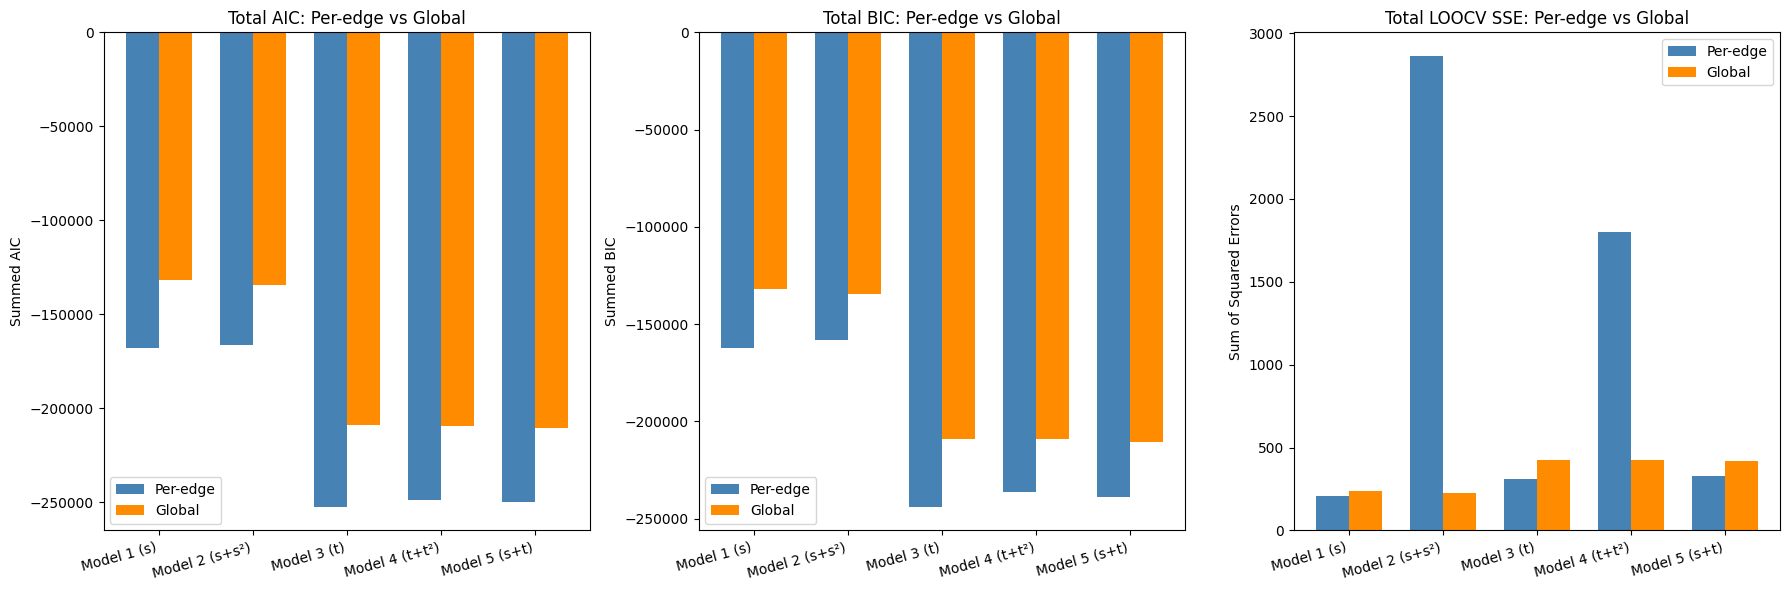

In [16]:
# Compare AIC, BIC, and LOOCV SSE between per-edge and global models
per_edge_models = [model1_results, model2_results, model3_results, model4_results, model5_results]
per_edge_sses   = [sse_model1,     sse_model2,     sse_model3,     sse_model4,     sse_model5]

# Aggregate per-edge metrics: sum AIC/BIC across all edges, sum SSE across all edges
per_edge_aic  = [sum(m.aic for m in res.values()) for res in per_edge_models]
per_edge_bic  = [sum(m.bic for m in res.values()) for res in per_edge_models]
per_edge_sse_total = [sum(sse.values()) for sse in per_edge_sses]

global_aic = [m.aic for m in global_models]
global_bic = [m.bic for m in global_models]

x = np.arange(len(model_labels))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# AIC
axes[0].bar(x - width/2, per_edge_aic,  width, label='Per-edge', color='steelblue')
axes[0].bar(x + width/2, global_aic,    width, label='Global',   color='darkorange')
axes[0].set_title('Total AIC: Per-edge vs Global')
axes[0].set_ylabel('Summed AIC')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_labels, rotation=15, ha='right')
axes[0].legend()

# BIC
axes[1].bar(x - width/2, per_edge_bic,  width, label='Per-edge', color='steelblue')
axes[1].bar(x + width/2, global_bic,    width, label='Global',   color='darkorange')
axes[1].set_title('Total BIC: Per-edge vs Global')
axes[1].set_ylabel('Summed BIC')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_labels, rotation=15, ha='right')
axes[1].legend()

# LOOCV SSE
axes[2].bar(x - width/2, per_edge_sse_total, width, label='Per-edge', color='steelblue')
axes[2].bar(x + width/2, global_sses,        width, label='Global',   color='darkorange')
axes[2].set_title('Total LOOCV SSE: Per-edge vs Global')
axes[2].set_ylabel('Sum of Squared Errors')
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_labels, rotation=15, ha='right')
axes[2].legend()

plt.tight_layout()
plt.show()


## Discussion: Per-edge vs Global Coefficients

### AIC / BIC
The per-edge models show more negative summed AIC/BIC than the global models. Per-edge models fit thousands of parameters (one set per edge), providing greater flexibility to fit the training data. The global models are restricted to 2–3 parameters total, incurring a smaller complexity penalty but reducing the overall training fit quality.

### LOOCV SSE and Overfitting
The Leave-One-Out Cross-Validation SSE highlights differences in out-of-sample prediction:
- **Overfitting in per-edge models:** For Models 2 and 4 (quadratic terms), the per-edge SSE is disproportionately high (~2850 and ~1800), driven by extreme prediction outliers on held-out subjects. Estimating a quadratic curve from only 19 data points per edge makes the model prone to overfitting. The global models pool all subjects and edges, providing sufficient data to stabilize the parameters and keep SSE low (223 and 427).
- **Direct vs. Indirect Connectivity:** Direct structural connectivity ('s', Models 1 & 2) yields a lower LOOCV SSE than indirect connectivity ('t', Models 3 & 4). This aligns with Honey et al. (2009), who noted that direct structural connections impose the strongest constraints on resting-state functional connectivity, although indirect paths also contribute.

### Dealing with Outliers via Regularization
The extreme SSE values in per-edge Models 2 and 4 are caused by unpenalized coefficients producing large errors on new data. Standard practice for handling these outliers in neuroimaging is not to remove them, but to apply regularization. As discussed by Deligianni et al. (2013), L1 (LASSO) or L2 (Ridge) regularization restricts coefficient magnitudes, inherently stabilizing predictions and preventing such outliers in small-sample, high-dimensional datasets.

### R² and Biological Interpretation
The global models yield low R² values (0.001–0.051), indicating that a single linear translation from structural to functional connectivity explains less than 5% of the variance. Deligianni et al. (2013) note that mapping structure to function across subjects is highly heterogeneous. Enforcing a single global slope oversimplifies this regional variability.

### Summary
The per-edge approach captures regional differences but overfits due to the small sample size, indicating that future iterations would benefit from regularized regression. The global approach prevents overfitting—making the global quadratic model (Model 2) numerically stable—but oversimplifies the spatially varying structure-function relationship.
